In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import tarfile
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(42)
np.random.seed(42)

# Original URL for the dataset, which is a .tgz archive
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.tgz"

# Download the .tgz file
filename = "housing.tgz"
urllib.request.urlretrieve(url, filename)

# Extract the .tgz file
housing_path = os.path.join("datasets", "housing")
os.makedirs(housing_path, exist_ok=True)
tar = tarfile.open(filename)
tar.extractall(path=housing_path)
tar.close()

# Read the extracted CSV file
csv_path = os.path.join(housing_path, "housing.csv")
df = pd.read_csv(csv_path)

print(df.head())
print(df.info())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

/tmp/ipykernel_2399/1827686843.py:30: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=housing_path)


In [36]:

print(df.shape)
print(df.head(3))

(20640, 10)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  


In [37]:
label_encoder = LabelEncoder()
df['ocean_proximity'] = label_encoder.fit_transform(df['ocean_proximity'])

# If you intend to use one-hot encoding for other categorical columns,
# you would apply it here. For the housing dataset, 'ocean_proximity'
# is often handled as a categorical feature, and Label Encoding
# or One-Hot Encoding can be used depending on the model.
# As an example, if we wanted to one-hot encode it instead:
# df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  ocean_proximity  
0       322.0       126.0         8.3252            452600.0                3  
1      2401.0      1138.0         8.3014            358500.0                3  
2       496.0       177.0         7.2574            352100.0                3  
3       558.0       219.0         5.6431            341300.0                3  
4       565.0       259.0         3.8462            342200.0                3  


In [38]:
df['is_high_value'] = (df['median_house_value'] > df['median_house_value'].median()).astype(int)

# Impute missing values in 'total_bedrooms' before splitting data
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

X = df.drop(['median_house_value', 'is_high_value'], axis=1)
y = df['is_high_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16512, 9)
X_test shape: (4128, 9)


In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Масштабтау аяқталды")

Масштабтау аяқталды


In [40]:
model = Sequential()

model.add(Dense(units=16, activation="relu", input_dim=X_train.shape[1]))
model.add(Dense(units=8, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7513 - loss: 0.5063 - val_accuracy: 0.8144 - val_loss: 0.4152
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8317 - loss: 0.3744 - val_accuracy: 0.8367 - val_loss: 0.3707
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.3494 - val_accuracy: 0.8435 - val_loss: 0.3578
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8513 - loss: 0.3412 - val_accuracy: 0.8469 - val_loss: 0.3527
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3368 - val_accuracy: 0.8496 - val_loss: 0.3492
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8562 - loss: 0.3336 - val_accuracy: 0.8513 - val_loss: 0.3468
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8569 - loss: 0.3313 - val_accuracy: 0.8537 - val_loss: 0.3450
Epoch 8/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8579 - loss: 0.3294 - val_accuracy: 0.

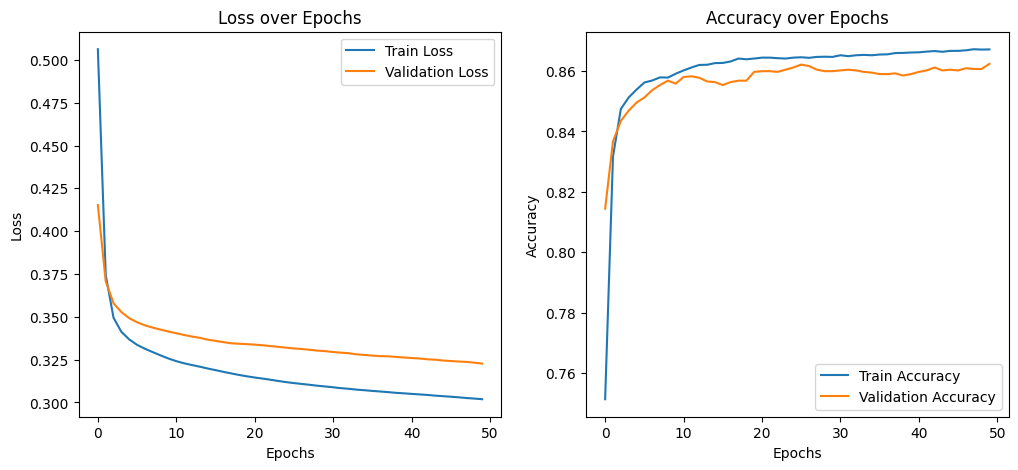

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [43]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Алғашқы 10 болжам ықтималдығы:")
print(y_pred_prob[:10])

print("Алғашқы 10 класс:")
print(y_pred[:10])

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Алғашқы 10 болжам ықтималдығы:
[[0.00671477]
 [0.02622706]
 [0.99628973]
 [0.9835349 ]
 [0.992964  ]
 [0.24081114]
 [0.95285815]
 [0.6144844 ]
 [0.93508935]
 [0.9969297 ]]
Алғашқы 10 класс:
[[0]
 [0]
 [1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]]


In [44]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1802  275]
 [ 293 1758]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      2077
           1       0.86      0.86      0.86      2051

    accuracy                           0.86      4128
   macro avg       0.86      0.86      0.86      4128
weighted avg       0.86      0.86      0.86      4128



In [45]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.3227
Test Accuracy: 0.8624


In [46]:
print(f"NaN values in X_train after scaling: {np.isnan(X_train).sum()}")
print(f"NaN values in X_test after scaling: {np.isnan(X_test).sum()}")

NaN values in X_train after scaling: 0
NaN values in X_test after scaling: 0


Test Loss: 0.3227 Бұл модельдің сынақ деректер жиынтығындағы шығын функциясының мәні. 0.3227 деген көрсеткіш модельдің болжамдары нақты мәндерден орташа есеппен қаншалықты ауытқитынын көрсетеді. Бұл мән неғұрлым төмен болса, модельдің өнімділігі соғұрлым жақсы болады.

Test Accuracy: 0.8624 Бұл модельдің сынақ деректер жиынтығындағы дұрыс болжамдарының пайызы. 0.8624 немесе 86.24% дәлдік модельдің нысана айнымалысын (яғни, үйдің құны жоғары ма, жоқ па) 86.24% жағдайда дұрыс жіктегенін көрсетеді. Бұл көрсеткіш модельдің жіктеу қабілетінің өте жақсы екенін білдіреді,